# 🏠 Grupo 4 — Ames Housing | Fase 3
## Notebook 05: Deep Learning — MLP Tabular con PyTorch
**CRISP-DM:** Modeling + Evaluation

| Paso | Descripción |
|------|-------------|
| 1 | MLP [263→512→256→128→1] definido en `src/deep_learning.py` |
| 2 | Entrenamiento con Adam + ReduceLROnPlateau + Early Stopping |
| 3 | Evaluación en test set (R², RMSE USD, MAE USD) |
| 4 | Comparación MLP vs Ridge vs XGBoost vs AutoML |
| 5 | Embeddings 128D → PCA 2D |
| 6 | Conclusión: DL vs ML clásico en datos tabulares |

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

project_root = os.getcwd()
while not os.path.exists(os.path.join(project_root, 'config', 'params.yaml')) and project_root != os.path.dirname(project_root):
    project_root = os.path.dirname(project_root)
os.chdir(project_root)
sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import torch

from src.preprocessing import load_config
from src.utils import set_plot_style, save_fig
from src.deep_learning import (
    MLPTabular, train_mlp, evaluate_mlp, extract_embeddings, DEVICE
)
from src.models import compute_metrics, build_comparison_table, print_metrics

set_plot_style()
cfg = load_config('config/params.yaml')

print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Imports OK')

PyTorch 2.12.0+cpu | Device: cpu
Imports OK


## 1. Cargar Datos Preprocesados

In [2]:
X_train = np.load('data/processed/X_train.npy').astype(np.float32)
X_val   = np.load('data/processed/X_val.npy').astype(np.float32)
X_test  = np.load('data/processed/X_test.npy').astype(np.float32)
y_train = np.load('data/processed/y_train.npy').astype(np.float32)
y_val   = np.load('data/processed/y_val.npy').astype(np.float32)
y_test  = np.load('data/processed/y_test.npy').astype(np.float32)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'Target rango: [${np.expm1(y_train.min()):,.0f} — ${np.expm1(y_train.max()):,.0f}]')

X_train: (2048, 263) | X_val: (439, 263) | X_test: (440, 263)
Target rango: [$12,789 — $755,000]


## 2. Arquitectura del MLP

Definida en `src/deep_learning.py → MLPTabular`

```
Input (263)  →  [Linear(512) → BN → ReLU → Dropout(0.3)]
             →  [Linear(256) → BN → ReLU → Dropout(0.3)]
             →  [Linear(128) → BN → ReLU → Dropout(0.3)]  ← embeddings
             →  Linear(1)
```

In [3]:
model_preview = MLPTabular(input_dim=X_train.shape[1])
total_params  = sum(p.numel() for p in model_preview.parameters() if p.requires_grad)
print(model_preview)
print(f'\nParámetros entrenables: {total_params:,}')

MLPTabular(
  (layer1): Sequential(
    (0): Linear(in_features=263, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (embedding): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)

Parámetros entrenables: 301,313


## 3. Entrenamiento

In [4]:
model, train_losses, val_losses, best_epoch = train_mlp(
    X_train, y_train,
    X_val,   y_val,
    cfg=cfg,
    save_path='models/mlp_tabular.pt'
)

Entrenando MLP — máx 200 épocas | early stopping paciencia=20 | device=cpu
 Época |   Train RMSE |   Val RMSE |         LR
--------------------------------------------------
     1 |    11.728039 |  11.680344 |   0.001000
    10 |     2.928905 |   2.730750 |   0.001000
    20 |     1.241735 |   0.553033 |   0.001000
    30 |     1.165834 |   0.360772 |   0.001000
    40 |     1.220938 |   0.469136 |   0.001000
    50 |     1.142580 |   0.399943 |   0.001000
    60 |     1.101539 |   0.278381 |   0.001000
    70 |     1.052514 |   0.322086 |   0.001000
    80 |     1.089944 |   0.258419 |   0.000500
    90 |     1.046241 |   0.240625 |   0.000500
   100 |     1.008727 |   0.241377 |   0.000250
   110 |     0.984815 |   0.202722 |   0.000250
   120 |     0.984939 |   0.250008 |   0.000250
   130 |     0.979501 |   0.210750 |   0.000125

Early stopping en época 133 | mejor: época 113
Mejor época: 113 | Mejor Val RMSE (log): 0.161651
Modelo guardado: models/mlp_tabular.pt


## 4. Curvas de Entrenamiento

[Fig] Guardada: reports/figures\25_mlp_training_curves.png


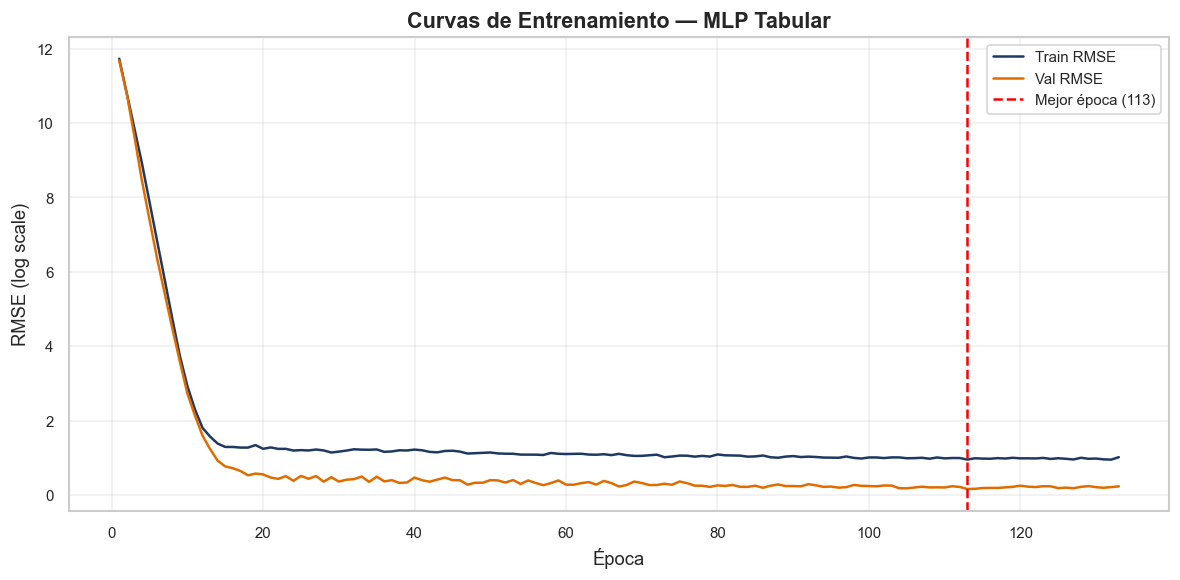

Gap val-train en mejor época: -0.7907


In [5]:
epochs_ran = len(train_losses)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, epochs_ran + 1), train_losses, label='Train RMSE', color='#1F3864', linewidth=1.5)
ax.plot(range(1, epochs_ran + 1), val_losses,   label='Val RMSE',   color='#E06C00', linewidth=1.5)
ax.axvline(x=best_epoch, color='red', linestyle='--', linewidth=1.5,
           label=f'Mejor época ({best_epoch})')
ax.set_xlabel('Época')
ax.set_ylabel('RMSE (log scale)')
ax.set_title('Curvas de Entrenamiento — MLP Tabular', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig('25_mlp_training_curves')
plt.show()

gap = val_losses[best_epoch - 1] - train_losses[best_epoch - 1]
print(f'Gap val-train en mejor época: {gap:.4f}')

## 5. Evaluación en Test Set

In [6]:
metrics_mlp = evaluate_mlp(model, X_test, y_test)
print_metrics('MLP Tabular', metrics_mlp)


──────────────────────────────────────────────────
  MLP Tabular
──────────────────────────────────────────────────
  RMSE (USD)  : $29,401
  MAE  (USD)  : $20,388
  R²          : 0.8619
  RMSE (log)  : 0.146266


## 6. Comparación Completa: Fase 2 vs Fase 3

In [7]:
ridge  = joblib.load('models/ridge_baseline.pkl')
rf     = joblib.load('models/random_forest.pkl')
xgb    = joblib.load('models/xgboost.pkl')
automl = joblib.load('models/automl_flaml.pkl')

results = {
    'Ridge (Baseline)': compute_metrics(y_test, ridge.predict(X_test)),
    'Random Forest':    compute_metrics(y_test, rf.predict(X_test)),
    'XGBoost':          compute_metrics(y_test, xgb.predict(X_test)),
    'AutoML FLAML':     compute_metrics(y_test, automl.predict(X_test)),
    'MLP Tabular':      metrics_mlp,
}

comp_df = build_comparison_table(results)
print('\n' + '='*65)
print('  TABLA COMPARATIVA — TEST SET (Fases 2 + 3)')
print('='*65)
print(comp_df.to_string())


  TABLA COMPARATIVA — TEST SET (Fases 2 + 3)
                      R² RMSE (USD) MAE (USD)  RMSE (log)
Modelo                                                   
Ridge (Baseline)  0.9359    $20,035   $13,398    0.116409
Random Forest     0.9017    $24,805   $14,972    0.125965
XGBoost           0.9219    $22,106   $13,576    0.115926
AutoML FLAML      0.9311    $20,773   $13,552    0.121906
MLP Tabular       0.8619    $29,401   $20,388    0.146266


[Fig] Guardada: reports/figures\26_mlp_vs_classical.png


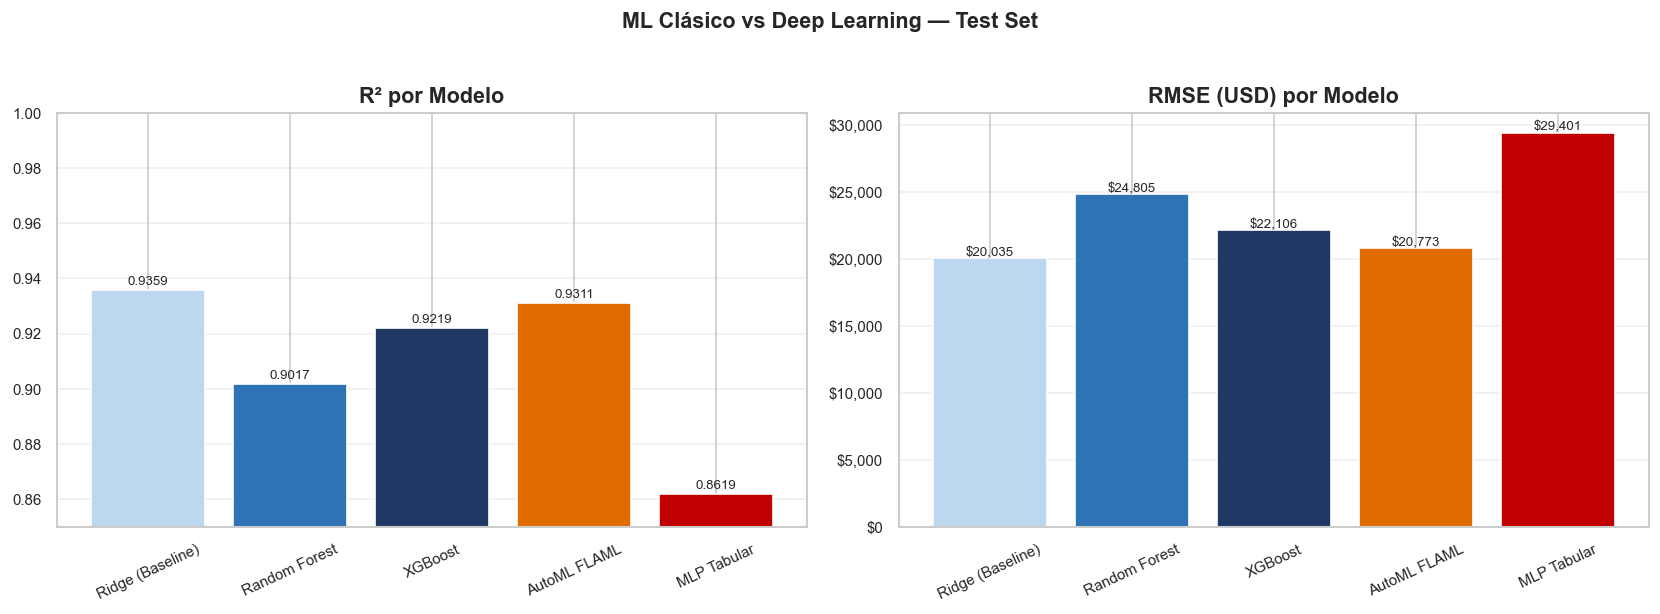

In [8]:
nombres = list(results.keys())
r2s     = [results[m]['R2']       for m in nombres]
rmses   = [results[m]['RMSE_USD'] for m in nombres]
colores = ['#BDD7EE', '#2E74B5', '#1F3864', '#E06C00', '#C00000']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(nombres, r2s, color=colores, edgecolor='white')
for bar, val in zip(bars1, r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=8)
axes[0].set_title('R² por Modelo', fontweight='bold')
axes[0].set_ylim(0.85, 1.0)
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(True, alpha=0.3, axis='y')

bars2 = axes[1].bar(nombres, rmses, color=colores, edgecolor='white')
for bar, val in zip(bars2, rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontsize=8)
axes[1].set_title('RMSE (USD) por Modelo', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('ML Clásico vs Deep Learning — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('26_mlp_vs_classical')
plt.show()

## 7. Embeddings — Representación Latente 128D

In [9]:
from sklearn.decomposition import PCA

X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

embeddings = extract_embeddings(model, X_all, save_path='models/mlp_embeddings.npy')

np.save('models/mlp_embeddings_labels.npy', np.expm1(y_all))
print('Labels USD guardados: models/mlp_embeddings_labels.npy')

Embeddings guardados: models/mlp_embeddings.npy  shape=(2927, 128)
Labels USD guardados: models/mlp_embeddings_labels.npy


[Fig] Guardada: reports/figures\27_mlp_embeddings_pca.png


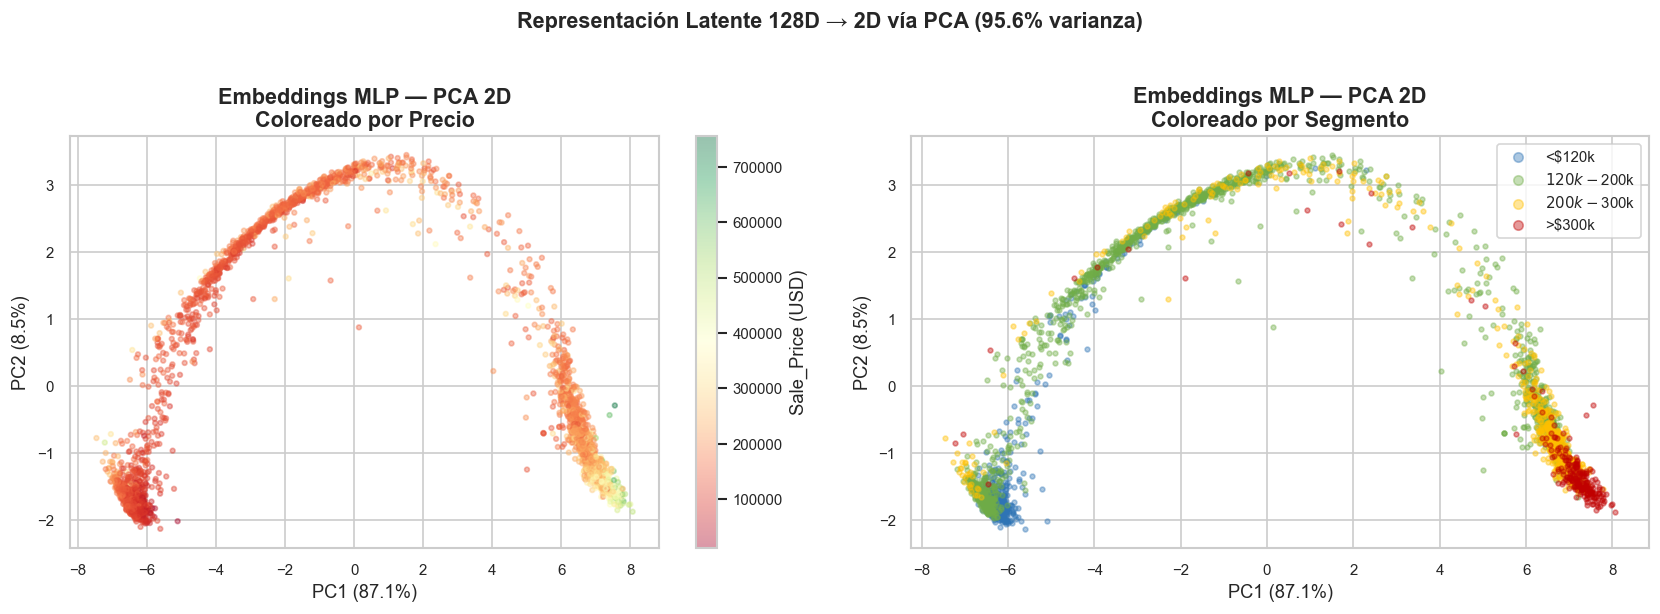

In [10]:
pca    = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)
prices = np.expm1(y_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=prices, cmap='RdYlGn', alpha=0.4, s=8)
plt.colorbar(sc, ax=axes[0], label='Sale_Price (USD)')
axes[0].set_title('Embeddings MLP — PCA 2D\nColoreado por Precio', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

segmentos = pd.cut(prices, bins=[0, 120000, 200000, 300000, 1e9],
                   labels=['<$120k', '$120k-$200k', '$200k-$300k', '>$300k'])
pal = {'<$120k': '#2E74B5', '$120k-$200k': '#70AD47', '$200k-$300k': '#FFC000', '>$300k': '#C00000'}
for seg, color in pal.items():
    mask = segmentos == seg
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=color, alpha=0.4, s=8, label=seg)
axes[1].set_title('Embeddings MLP — PCA 2D\nColoreado por Segmento', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=9, markerscale=2)

var_total = sum(pca.explained_variance_ratio_) * 100
plt.suptitle(f'Representación Latente 128D → 2D vía PCA ({var_total:.1f}% varianza)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('27_mlp_embeddings_pca')
plt.show()

## 8. Conclusión Técnica

In [11]:
mejor    = max(results, key=lambda m: results[m]['R2'])
mlp_r2   = results['MLP Tabular']['R2']
ridge_r2 = results['Ridge (Baseline)']['R2']

print('='*60)
print('  CONCLUSIÓN — FASE 3: DL vs ML CLÁSICO EN DATOS TABULARES')
print('='*60)
print(f'  Mejor modelo global : {mejor} (R²={results[mejor]["R2"]:.4f})')
print(f'  MLP R²              : {mlp_r2:.4f}')
print(f'  Ridge R²            : {ridge_r2:.4f} (baseline)')
print(f'  Diferencia MLP-Ridge: {mlp_r2 - ridge_r2:+.4f}')
print()
print('  DL CONVIENE CUANDO:')
print('  ✓ Datasets grandes (>10k filas)')
print('  ✓ Se necesitan embeddings para búsqueda de similitud (Fase 4)')
print('  ✓ Interacciones muy no lineales entre features')
print()
print('  DL NO CONVIENE CUANDO:')
print('  ✗ Pocos datos (~2,900 filas) → XGBoost/AutoML generalizan mejor')
print('  ✗ Se requiere interpretabilidad (Ridge + SHAP gana)')
print('  ✗ Sin GPU y con presupuesto de tiempo limitado')
print()
print('  VALOR CLAVE EN ESTE PROYECTO:')
print('  → Los embeddings 128D se usan en Fase 4 para búsqueda')
print('    de propiedades similares (RAG / FAISS).')
print('='*60)

  CONCLUSIÓN — FASE 3: DL vs ML CLÁSICO EN DATOS TABULARES
  Mejor modelo global : Ridge (Baseline) (R²=0.9359)
  MLP R²              : 0.8619
  Ridge R²            : 0.9359 (baseline)
  Diferencia MLP-Ridge: -0.0740

  DL CONVIENE CUANDO:
  ✓ Datasets grandes (>10k filas)
  ✓ Se necesitan embeddings para búsqueda de similitud (Fase 4)
  ✓ Interacciones muy no lineales entre features

  DL NO CONVIENE CUANDO:
  ✗ Pocos datos (~2,900 filas) → XGBoost/AutoML generalizan mejor
  ✗ Se requiere interpretabilidad (Ridge + SHAP gana)
  ✗ Sin GPU y con presupuesto de tiempo limitado

  VALOR CLAVE EN ESTE PROYECTO:
  → Los embeddings 128D se usan en Fase 4 para búsqueda
    de propiedades similares (RAG / FAISS).


## 9. Autoencoder Tabular

El **Autoencoder** aprende a comprimir las 263 features a un espacio latente de **32 dimensiones** y luego reconstruirlas. A diferencia del MLP (supervisado), el Autoencoder es **no supervisado**: no usa Sale_Price, solo aprende la estructura de los datos.

Los embeddings 32D resultantes son una alternativa compacta a los 128D del MLP para la búsqueda de similitud.

Arquitectura:


In [12]:
from src.deep_learning import (
    TabularAutoencoder, train_autoencoder,
    extract_ae_embeddings, load_autoencoder
)

ae_cfg = cfg["models"]["autoencoder"]
print(f'Autoencoder config: latent_dim={ae_cfg["latent_dim"]} | epochs={ae_cfg["epochs"]} | lr={ae_cfg["lr"]}')

Autoencoder config: latent_dim=32 | epochs=150 | lr=0.001


In [13]:
# Entrenamiento del Autoencoder (no supervisado — sin usar Sale_Price)
ae_model, ae_train_losses, ae_val_losses, ae_best_epoch = train_autoencoder(
    X_train, X_val,
    cfg=cfg,
    latent_dim=ae_cfg["latent_dim"],
    save_path="models/autoencoder.pt"
)

Autoencoder — 263D → 32D latente | params=89,319
 Época |    Train MSE |    Val MSE |         LR
--------------------------------------------------
     1 |     0.413431 |   0.275028 |   0.001000
    10 |     0.175234 |   0.147474 |   0.001000
    20 |     0.151490 |   0.128990 |   0.001000
    30 |     0.137190 |   0.118958 |   0.001000
    40 |     0.128086 |   0.112127 |   0.001000
    50 |     0.121999 |   0.106314 |   0.001000
    60 |     0.115940 |   0.101820 |   0.001000
    70 |     0.112477 |   0.097015 |   0.001000
    80 |     0.109106 |   0.093550 |   0.001000
    90 |     0.106367 |   0.090975 |   0.001000
   100 |     0.106211 |   0.088689 |   0.001000
   110 |     0.103750 |   0.087026 |   0.001000
   120 |     0.102825 |   0.085862 |   0.001000
   130 |     0.101682 |   0.084600 |   0.001000
   140 |     0.101694 |   0.083048 |   0.001000
   150 |     0.098987 |   0.081820 |   0.001000
Mejor época: 150 | Mejor Val MSE: 0.081820
Modelo guardado: models/autoencoder.pt


[Fig] Guardada: reports/figures\32_autoencoder_training.png


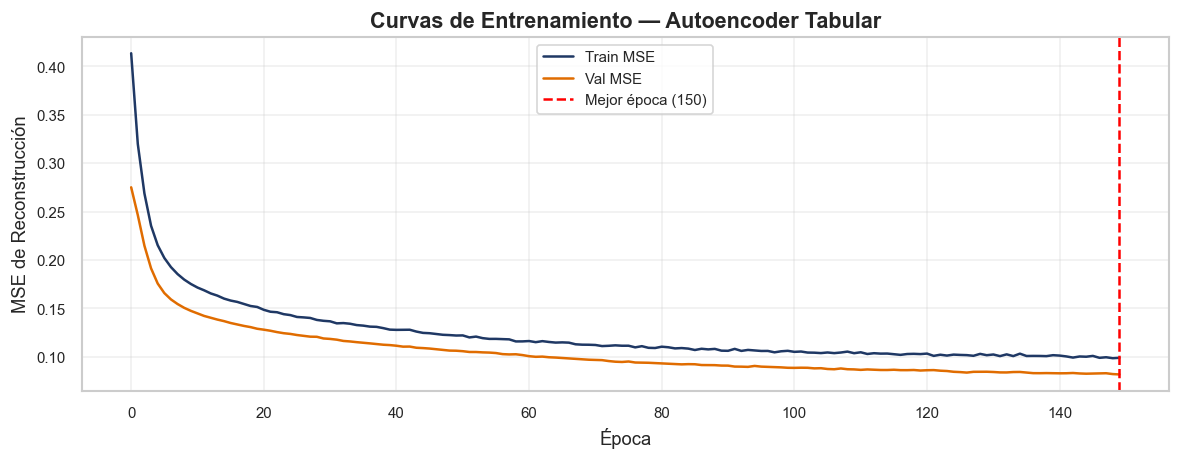

In [14]:
# Curvas de entrenamiento del Autoencoder
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ae_train_losses, label="Train MSE", color="#1F3864", linewidth=1.5)
ax.plot(ae_val_losses,   label="Val MSE",   color="#E06C00", linewidth=1.5)
ax.axvline(x=ae_best_epoch-1, color="red", linestyle="--", linewidth=1.5,
           label=f"Mejor época ({ae_best_epoch})")
ax.set_xlabel("Época")
ax.set_ylabel("MSE de Reconstrucción")
ax.set_title("Curvas de Entrenamiento — Autoencoder Tabular", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("32_autoencoder_training")
plt.show()

In [15]:
# Extraer embeddings 32D para todo el dataset
ae_embeddings = extract_ae_embeddings(
    ae_model, X_all,
    save_path="models/ae_embeddings.npy"
)

print(f"Shape embeddings AE: {ae_embeddings.shape}")
print(f"MLP embeddings:      {embeddings.shape}")
print(f"Compresion AE: {X_all.shape[1]} → {ae_embeddings.shape[1]} dims ({ae_embeddings.shape[1]/X_all.shape[1]*100:.1f}% del espacio original)")

AE Embeddings guardados: models/ae_embeddings.npy  shape=(2927, 32)
Shape embeddings AE: (2927, 32)
MLP embeddings:      (2927, 128)
Compresion AE: 263 → 32 dims (12.2% del espacio original)


[Fig] Guardada: reports/figures\33_ae_embeddings_pca.png


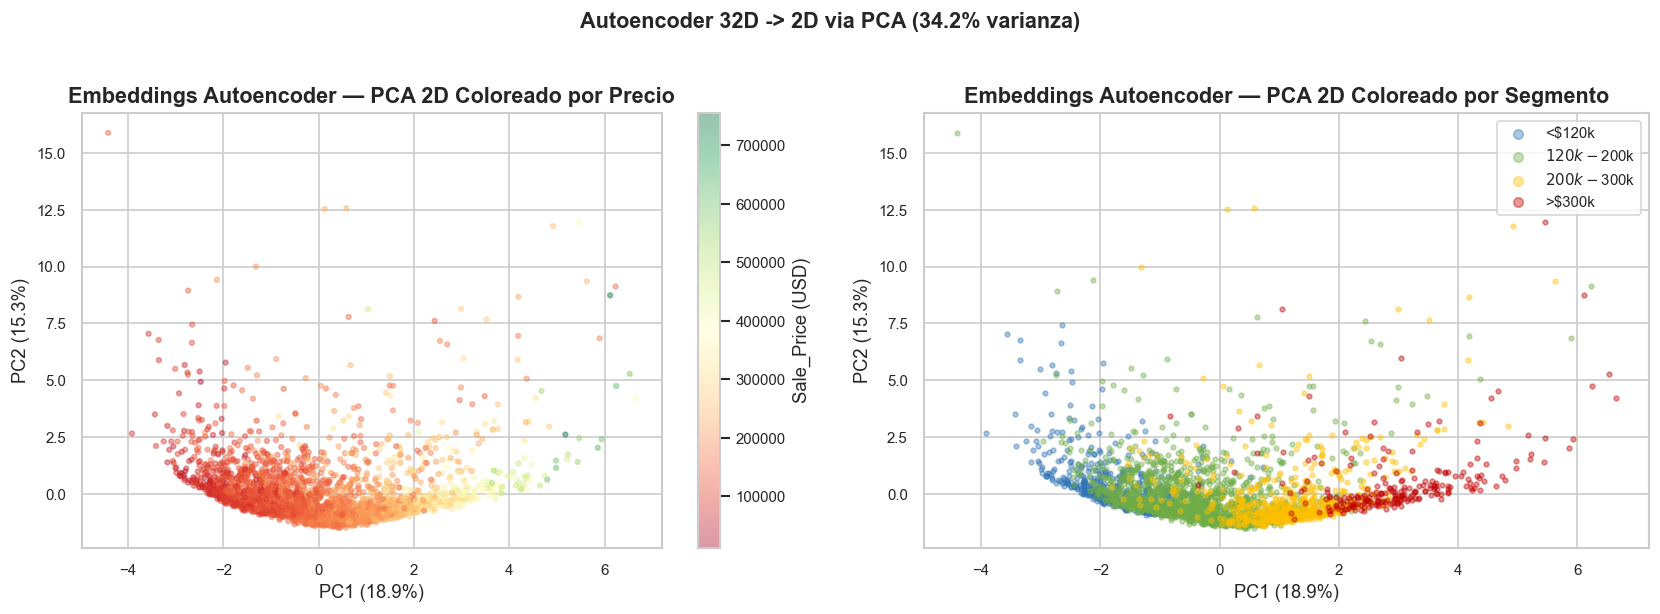

In [18]:
# Visualizacion PCA 2D de embeddings del Autoencoder
from sklearn.decomposition import PCA

pca_ae = PCA(n_components=2, random_state=42)
ae_2d  = pca_ae.fit_transform(ae_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(ae_2d[:, 0], ae_2d[:, 1], c=prices, cmap="RdYlGn", alpha=0.4, s=8)
plt.colorbar(sc, ax=axes[0], label="Sale_Price (USD)")
axes[0].set_title("Embeddings Autoencoder — PCA 2D Coloreado por Precio", fontweight="bold")
axes[0].set_xlabel(f'PC1 ({pca_ae.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_ae.explained_variance_ratio_[1]*100:.1f}%)')

for seg, color in pal.items():
    mask = segmentos == seg
    axes[1].scatter(ae_2d[mask, 0], ae_2d[mask, 1], c=color, alpha=0.4, s=8, label=seg)
axes[1].set_title("Embeddings Autoencoder — PCA 2D Coloreado por Segmento", fontweight="bold")
axes[1].set_xlabel(f'PC1 ({pca_ae.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_ae.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=9, markerscale=2)

var_ae = sum(pca_ae.explained_variance_ratio_) * 100
plt.suptitle(f"Autoencoder 32D -> 2D via PCA ({var_ae:.1f}% varianza)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("33_ae_embeddings_pca")
plt.show()

### Conclusión: MLP Embeddings vs Autoencoder Embeddings

| Característica | MLP (128D) | Autoencoder (32D) |
|---|---|---|
| Supervisión | Supervisado (usa Sale_Price) | No supervisado (solo features) |
| Dimensión | 128D | 32D |
| Propósito primario | Predicción + embeddings | Compresión + embeddings |
| Uso en RAG | ✓ Implementado en Fase 4 | ✓ Alternativa compacta |

Ambos enfoques generan representaciones útiles para la búsqueda de propiedades similares. Los embeddings del MLP capturan información relacionada con el precio; los del Autoencoder capturan la estructura general de las features independientemente del precio.